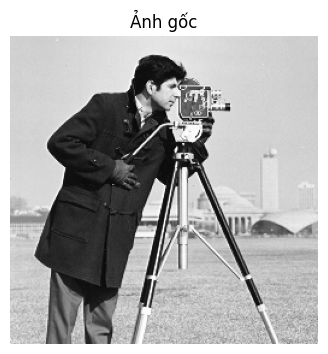

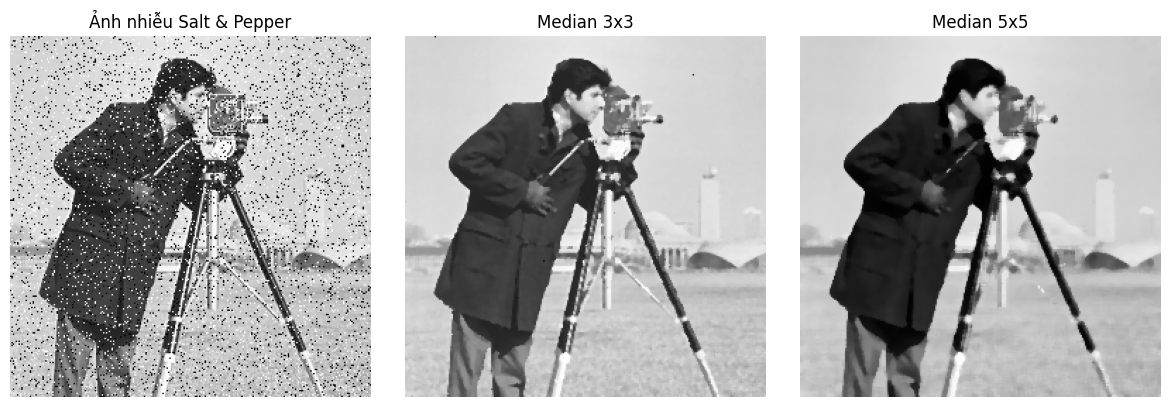

Kích thước ảnh gốc: (256, 256)
Kích thước ảnh nhiễu: (256, 256)
Kích thước ảnh sau lọc Median 3x3: (256, 256)
Kích thước ảnh sau lọc Median 5x5: (256, 256)
Kiểu dữ liệu ảnh gốc: uint8
Kiểu dữ liệu ảnh sau lọc: uint8
Số điểm ảnh bị gán về 0: 3291
Số điểm ảnh bị gán về 255: 3409


In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: LỌC MEDIAN KHỬ NHIỄU SALT & PEPPER
# Chương/Mục liên quan: Chương 4 - Lọc ảnh trong miền không gian
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa bài toán khử nhiễu Salt & Pepper bằng bộ lọc Median.
# - Giúp người học quan sát tác động của kích thước cửa sổ lọc 3x3 và 5x5.
# - Liên hệ phần code với thuật toán lọc phi tuyến trong miền không gian.

# Sau khi chạy code, người học cần:
# 1. Quan sát được ảnh sau khi thêm nhiễu Salt & Pepper.
# 2. So sánh kết quả khử nhiễu khi dùng cửa sổ Median 3x3 và 5x5.
# 3. Hiểu được ảnh hưởng của kích thước cửa sổ lọc đến mức độ làm mượt ảnh.

# Input:
# - Dữ liệu đầu vào: ảnh cameraman.png từ GitHub
# - Kiểu dữ liệu: ảnh xám

# Output:
# - Ảnh nhiễu Salt & Pepper
# - Ảnh sau lọc Median 3x3
# - Ảnh sau lọc Median 5x5

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

def read_gitlab_image(url):
    resp = urlopen(url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(img, cv2.IMREAD_GRAYSCALE)

image_uri = "https://github.com/lthavnu/cv-book/raw/main/images/cameraman.png"

I = read_gitlab_image(image_uri)

if I is None:
    raise FileNotFoundError("Không tìm thấy file cameraman.png")

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

plt.figure(figsize=(4, 4))
plt.imshow(I, cmap='gray')
plt.title('Ảnh gốc')
plt.axis('off')
plt.show()

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

# 4.1. Thêm nhiễu Salt & Pepper vào ảnh
rnd = np.random.rand(*I.shape)

In = I.copy()
In[rnd < 0.05] = 0
In[rnd > 0.95] = 255

# 4.2. Lọc Median với cửa sổ 3x3 và 5x5
# Dòng lệnh cv2.medianBlur tương ứng với bước lấy trung vị
# của các mức xám trong lân cận cửa sổ lọc.
Im3 = cv2.medianBlur(In, 3)
Im5 = cv2.medianBlur(In, 5)

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(In, cmap='gray')
plt.title('Ảnh nhiễu Salt & Pepper')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(Im3, cmap='gray')
plt.title('Median 3x3')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(Im5, cmap='gray')
plt.title('Median 5x5')
plt.axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

print("Kích thước ảnh gốc:", I.shape)
print("Kích thước ảnh nhiễu:", In.shape)
print("Kích thước ảnh sau lọc Median 3x3:", Im3.shape)
print("Kích thước ảnh sau lọc Median 5x5:", Im5.shape)

print("Kiểu dữ liệu ảnh gốc:", I.dtype)
print("Kiểu dữ liệu ảnh sau lọc:", Im3.dtype)

print("Số điểm ảnh bị gán về 0:", np.sum(In == 0))
print("Số điểm ảnh bị gán về 255:", np.sum(In == 255))

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi xác suất nhiễu bằng cách sửa các ngưỡng 0.05 và 0.95.
# 2. Thay đổi kích thước cửa sổ Median, ví dụ 7 hoặc 9.
# 3. So sánh ảnh sau lọc với ảnh gốc để đánh giá mức độ khử nhiễu và làm mờ chi tiết.